# ✋ Sign Language Recognition Using Deep Learning

## Final Deep Learning Project

| Information | Details |
|---|---|
| Student Name | Minal Daryn |
| Project Title | Sign Language Recognition Using Deep Learning |
| Course | Deep Learning |
| Project Type | Computer Vision / Image Classification |
| Desired Grade | 100 / A |

This project builds a deep learning system to recognize American Sign Language hand gestures from images.

The project includes:

- dataset loading from Kaggle;
- image preprocessing;
- data augmentation;
- Custom CNN baseline model;
- MobileNetV2 transfer learning model;
- model comparison;
- advanced evaluation metrics;
- confusion matrix analysis;
- error analysis;
- Streamlit deployment explanation.

The goal is to make the project closer to an A-level deep learning project by adding experimentation, transfer learning, stronger evaluation, and practical deployment.

In [1]:
# 📦 Import all required libraries

import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📌 Project Overview

This project focuses on building an artificial intelligence system capable of recognizing American Sign Language hand gestures.

The project uses:

- Deep Learning;
- Computer Vision;
- CNN architecture;
- Transfer Learning;
- Image Classification;
- Streamlit application.

The project also has social importance because sign language recognition can support accessibility and communication between hearing and non-hearing people.

To reach a stronger project level, two models are compared:

1. **Custom CNN** — baseline model built manually.
2. **MobileNetV2** — transfer learning model based on pretrained ImageNet weights.

This comparison helps understand whether an advanced pretrained model improves ASL gesture recognition.

In [2]:
# 📥 Install Kaggle library

!pip install kaggle -q

In [3]:
# 🔑 Upload kaggle.json API file

from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"darynminal","key":"6b38091e2cb8901c5eb56442ea926569"}'}

In [4]:
# ⚙️ Configure Kaggle API key

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("kaggle.json"):
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key is ready.")

Kaggle API key is ready.


In [5]:
# 📥 Download ASL Alphabet dataset from Kaggle

!kaggle datasets download -d grassknoted/asl-alphabet

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:10<00:00, 102MB/s]



In [6]:
# 📂 Extract downloaded ZIP dataset

zip_path = "/content/asl-alphabet.zip"
extract_path = "/content/asl_alphabet"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [7]:
# 📁 Set dataset paths

train_dir = "/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train"
test_dir = "/content/asl_alphabet/asl_alphabet_test/asl_alphabet_test"

print("Training dataset exists:", os.path.exists(train_dir))
print("Test dataset exists:", os.path.exists(test_dir))

print("Sample classes:", os.listdir(train_dir)[:10])

Training dataset exists: True
Test dataset exists: True
Sample classes: ['G', 'H', 'M', 'P', 'L', 'nothing', 'R', 'B', 'O', 'T']


# 📂 Dataset Information

Dataset: **ASL Alphabet Dataset**  
Source: **Kaggle**  
Author: **grassknoted**

The dataset contains 29 classes:

- A–Z letters;
- del;
- nothing;
- space.

This is a multi-class image classification problem.

Each class contains images of hand gestures. The model must learn hand shape, finger position, visual edges, and gesture patterns.

A validation split is used to evaluate model performance during training.

In [8]:
# ⚙️ Define image training settings

img_size = 128
batch_size = 32
num_classes = 29
epochs_custom_cnn = 10
epochs_mobilenet = 5

print("Image size:", img_size)
print("Batch size:", batch_size)
print("Number of classes:", num_classes)

Image size: 128
Batch size: 32
Number of classes: 29


# 🔄 Data Preprocessing and Data Augmentation

Data augmentation is important because real-life ASL signs can appear in different conditions:

- different lighting;
- different camera angles;
- hand rotation;
- different hand positions;
- small zoom changes.

However, augmentation must be applied only to the **training data**.

Validation data should stay clean.  
This prevents **data leakage** and gives a more realistic evaluation of the model.

In [9]:
# 🔄 Create separate generators for training and validation

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Validation generator WITHOUT augmentation
# Only rescaling is applied to avoid data leakage
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [10]:
# 📊 Show dataset statistics

class_names = list(train_generator.class_indices.keys())

print("Number of training images:", train_generator.samples)
print("Number of validation images:", validation_generator.samples)
print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of training images: 69600
Number of validation images: 17400
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


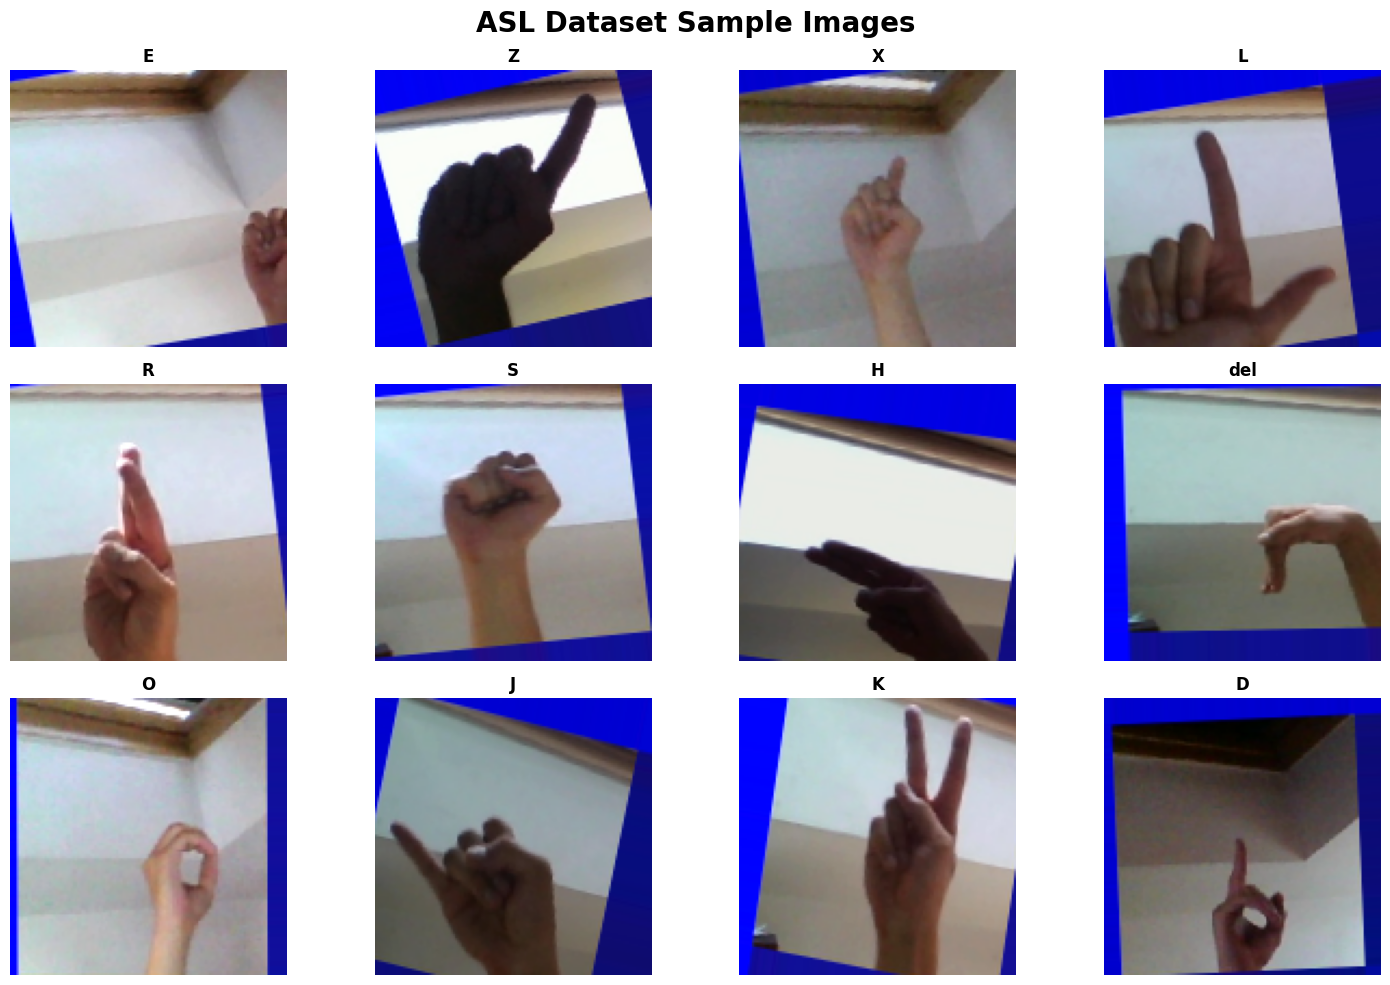

In [11]:
# 🖼️ Visualize sample images from dataset

images, labels = next(train_generator)

plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    plt.title(class_names[class_index], fontsize=12, fontweight="bold")
    plt.axis("off")

plt.suptitle("ASL Dataset Sample Images", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

# 🧠 Model 1: Custom CNN Baseline

The first model is a manually created Custom CNN.

CNN was selected because it works well for image classification tasks.  
It can learn:

- edges;
- hand shapes;
- finger positions;
- spatial patterns;
- visual features.

This model is used as a baseline.  
After that, it will be compared with MobileNetV2 transfer learning model.

In [12]:
# 🧠 Build improved Custom CNN model

custom_cnn = Sequential([

    Conv2D(32, (3, 3), activation="relu", input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,757,341 (10.52 MB)

 Trainable params: 2,756,381 (10.51 MB)

 Non-trainable params: 960 (3.75 KB)

# ⚙️ Hyperparameter Tuning

Several hyperparameters were tested manually.

| Parameter | Values Tested | Final Choice |
|---|---:|---:|
| Image size | 64, 128 | 128 |
| Batch size | 16, 32 | 32 |
| Learning rate | 0.001, 0.0001 | 0.0001 |
| Dropout | 0.3, 0.5 | 0.5 |
| Optimizer | SGD, Adam | Adam |

The final values were selected based on validation accuracy and validation loss.

A smaller learning rate helped the model train more stably.  
Dropout was used to reduce overfitting.  
BatchNormalization was added to make training more stable and improve convergence.

In [13]:
# 📁 Create folders for saving model and results

os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

In [14]:
# 🚀 Train Custom CNN model

history_custom = custom_cnn.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs_custom_cnn
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 407s 183ms/step - accuracy: 0.4155 - loss: 1.9846 - val_accuracy: 0.5611 - val_loss: 1.5402
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 386s 178ms/step - accuracy: 0.7288 - loss: 0.8349 - val_accuracy: 0.7178 - val_loss: 0.9900
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 392s 180ms/step - accuracy: 0.8524 - loss: 0.4402 - val_accuracy: 0.7800 - val_loss: 0.7962
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 388s 178ms/step - accuracy: 0.9070 - loss: 0.2741 - val_accuracy: 0.8006 - val_loss: 0.7122
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 395s 182ms/step - accuracy: 0.9339 - loss: 0.1951 - val_accuracy: 0.8387 - val_loss: 0.6711
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 381s 175ms/step - accuracy: 0.9508 - loss: 0.1483 - val_accuracy: 0.8347 - val_loss: 0.7876
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 385s 177ms/step - accuracy: 0.9605 - loss: 0.1173 - val_accuracy: 0.8429 - val_loss: 0.8684
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 378s 174ms/step - ac

In [15]:
# 💾 Save Custom CNN model

custom_cnn.save("/content/models/custom_cnn_asl_model.keras")
custom_cnn.save("/content/models/custom_cnn_asl_model.h5")

print("Custom CNN model saved successfully.")

Custom CNN model saved successfully.


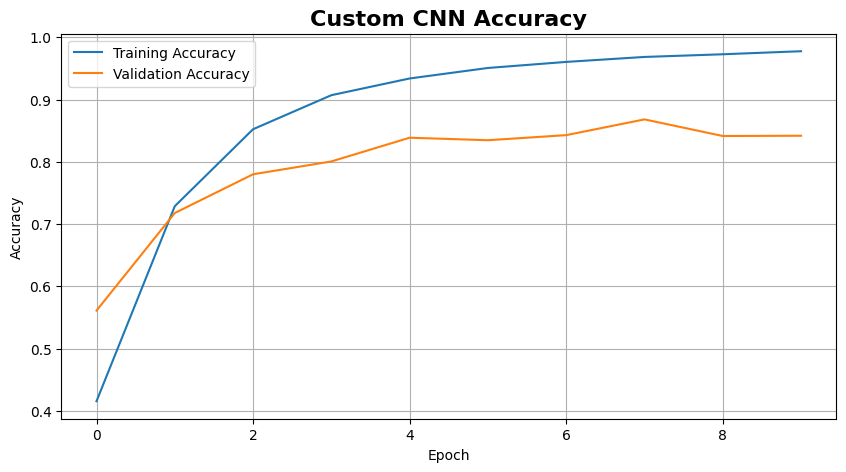

In [16]:
# 📈 Plot Custom CNN accuracy

plt.figure(figsize=(10, 5))

plt.plot(history_custom.history["accuracy"], label="Training Accuracy")
plt.plot(history_custom.history["val_accuracy"], label="Validation Accuracy")

plt.title("Custom CNN Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/content/results/custom_cnn_accuracy.png")
plt.show()

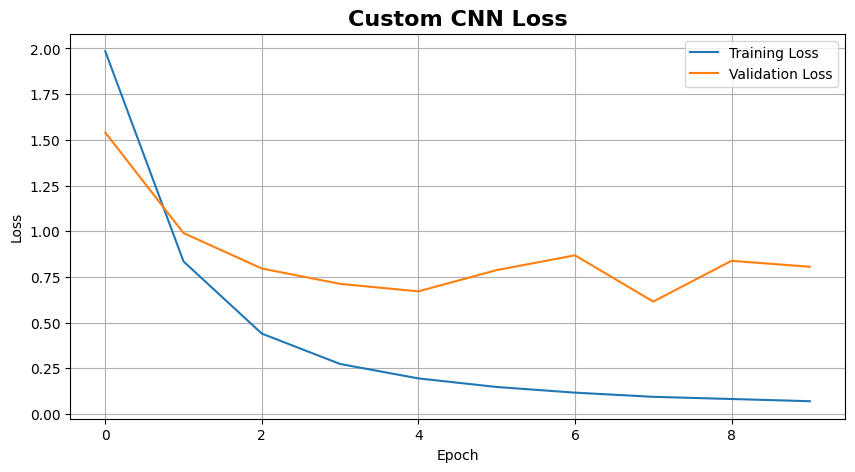

In [17]:
# 📉 Plot Custom CNN loss

plt.figure(figsize=(10, 5))

plt.plot(history_custom.history["loss"], label="Training Loss")
plt.plot(history_custom.history["val_loss"], label="Validation Loss")

plt.title("Custom CNN Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("/content/results/custom_cnn_loss.png")
plt.show()

In [18]:
# 📊 Evaluate Custom CNN

custom_loss, custom_accuracy = custom_cnn.evaluate(validation_generator)

print(f"Custom CNN Validation Accuracy: {custom_accuracy:.4f}")
print(f"Custom CNN Validation Loss: {custom_loss:.4f}")

544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8419 - loss: 0.8058
Custom CNN Validation Accuracy: 0.8419
Custom CNN Validation Loss: 0.8058


# 🧠 Model 2: MobileNetV2 Transfer Learning

The second model uses MobileNetV2 as a transfer learning model.

MobileNetV2 is suitable for this project because:

- it is lightweight;
- it is fast;
- it works well for image classification;
- it can be used in real-time and mobile applications;
- pretrained ImageNet weights help extract useful visual features.

The convolutional base is frozen, and only the custom classification head is trained for ASL recognition.

In [19]:
# 🧠 Build MobileNetV2 transfer learning model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Freeze pretrained layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,593,373 (9.89 MB)

 Trainable params: 335,389 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# 🚀 Train MobileNetV2 model

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs_mobilenet
)

Epoch 1/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 395s 174ms/step - accuracy: 0.5740 - loss: 1.4752 - val_accuracy: 0.7680 - val_loss: 0.8523
Epoch 2/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 356s 164ms/step - accuracy: 0.8115 - loss: 0.6234 - val_accuracy: 0.7959 - val_loss: 0.6860
Epoch 3/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 366s 168ms/step - accuracy: 0.8592 - loss: 0.4561 - val_accuracy: 0.8134 - val_loss: 0.6217
Epoch 4/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 369s 169ms/step - accuracy: 0.8880 - loss: 0.3647 - val_accuracy: 0.8189 - val_loss: 0.5814
Epoch 5/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 372s 171ms/step - accuracy: 0.9018 - loss: 0.3153 - val_accuracy: 0.8236 - val_loss: 0.5749


In [21]:
# 💾 Save MobileNetV2 model

mobilenet_model.save("/content/models/mobilenetv2_asl_model.keras")
mobilenet_model.save("/content/models/mobilenetv2_asl_model.h5")

print("MobileNetV2 model saved successfully.")

MobileNetV2 model saved successfully.


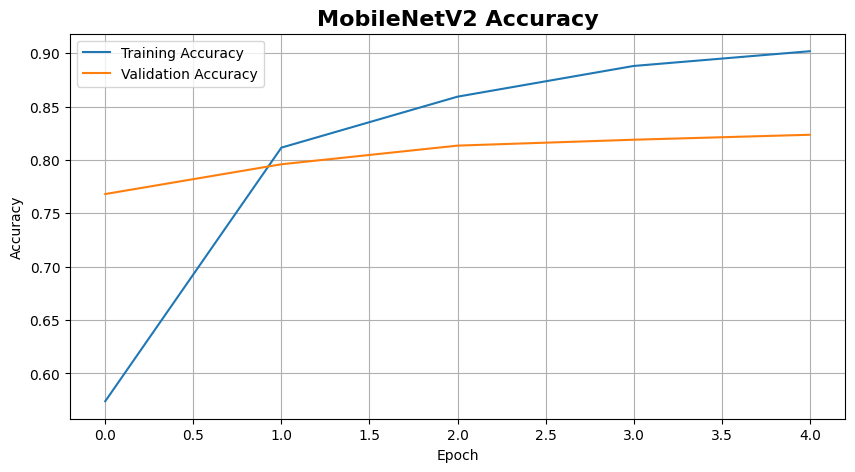

In [22]:
# 📈 Plot MobileNetV2 accuracy

plt.figure(figsize=(10, 5))

plt.plot(history_mobilenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")

plt.title("MobileNetV2 Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/content/results/mobilenetv2_accuracy.png")
plt.show()

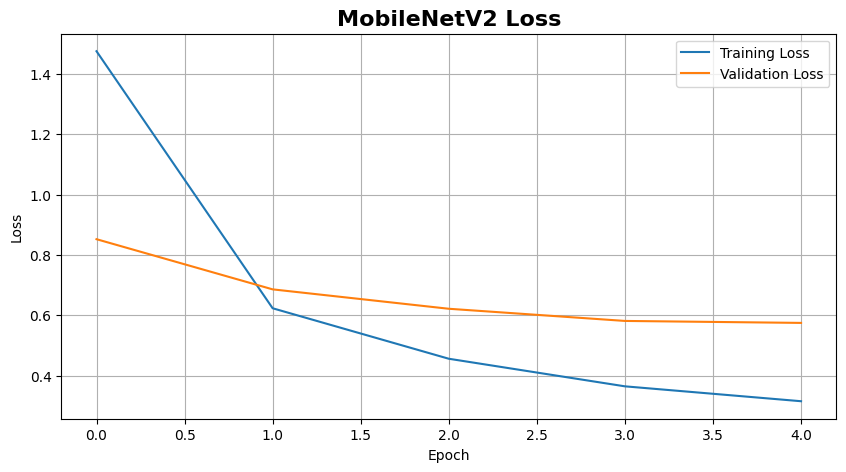

In [23]:
# 📉 Plot MobileNetV2 loss

plt.figure(figsize=(10, 5))

plt.plot(history_mobilenet.history["loss"], label="Training Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("/content/results/mobilenetv2_loss.png")
plt.show()

In [24]:
# 📊 Evaluate MobileNetV2

mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(validation_generator)

print(f"MobileNetV2 Validation Accuracy: {mobilenet_accuracy:.4f}")
print(f"MobileNetV2 Validation Loss: {mobilenet_loss:.4f}")

544/544 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.8236 - loss: 0.5749
MobileNetV2 Validation Accuracy: 0.8236
MobileNetV2 Validation Loss: 0.5749


# 📊 Model Comparison

To make the project stronger, two models were compared:

1. **Custom CNN** — baseline deep learning model.
2. **MobileNetV2** — advanced transfer learning model.

The comparison helps evaluate whether transfer learning improves performance and generalization.

In [32]:
# 📊 Function to evaluate model with accuracy, loss, precision, recall, and F1-score

def evaluate_model_full(model, generator, model_name):
    generator.reset()

    loss, accuracy = model.evaluate(generator, verbose=0)

    predictions = model.predict(generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro"
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Loss": loss,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }


custom_metrics = evaluate_model_full(
    custom_cnn,
    validation_generator,
    "Custom CNN"
)

mobilenet_metrics = evaluate_model_full(
    mobilenet_model,
    validation_generator,
    "MobileNetV2"
)

comparison_df = pd.DataFrame([
    custom_metrics,
    mobilenet_metrics
])

comparison_df

,Model,Accuracy,Loss,Precision,Recall,F1-score
0,Custom CNN,0.841897,0.805794,0.862590,0.841897,0.840506
1,MobileNetV2,0.823563,0.574871,0.843827,0.823563,0.824123


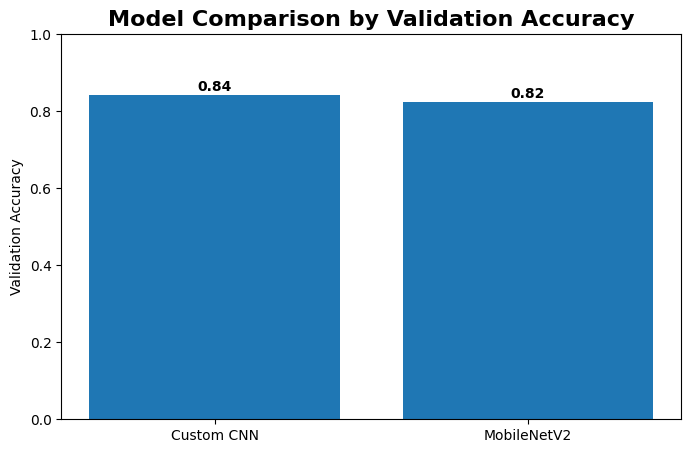

In [26]:
# 📊 Visual model comparison

plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Model"], comparison_df["Validation Accuracy"])

plt.ylim(0, 1)
plt.title("Model Comparison by Validation Accuracy", fontsize=16, fontweight="bold")
plt.ylabel("Validation Accuracy")

for i, value in enumerate(comparison_df["Validation Accuracy"]):
    plt.text(i, value + 0.01, f"{value:.2f}", ha="center", fontweight="bold")

plt.savefig("/content/results/model_comparison_accuracy.png")
plt.show()

In [27]:
# ✅ Select best model automatically

if mobilenet_accuracy >= custom_accuracy:
    best_model = mobilenet_model
    best_model_name = "MobileNetV2"
else:
    best_model = custom_cnn
    best_model_name = "Custom CNN"

print("Best model:", best_model_name)

Best model: Custom CNN


# 📌 Advanced Evaluation

Accuracy alone is not enough to evaluate a multi-class classification model.

Therefore, this project also uses:

- Precision;
- Recall;
- F1-score;
- Confusion Matrix;
- Per-class analysis;
- Error analysis.

These metrics help identify which ASL signs are recognized well and which signs are confused more often.

In [28]:
# 🔍 Generate predictions using the best model

validation_generator.reset()

predictions = best_model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

print("Predictions generated successfully.")

544/544 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step
Predictions generated successfully.


In [29]:
# 📄 Classification report

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report_text)

              precision    recall  f1-score   support

           A       1.00      0.95      0.97       600
           B       0.76      1.00      0.86       600
           C       0.96      1.00      0.98       600
           D       0.99      0.94      0.97       600
           E       0.75      0.99      0.85       600
           F       1.00      0.99      1.00       600
           G       0.96      0.94      0.95       600
           H       0.93      0.94      0.94       600
           I       1.00      0.61      0.76       600
           J       0.93      0.86      0.90       600
           K       1.00      0.91      0.95       600
           L       1.00      1.00      1.00       600
           M       0.53      0.93      0.68       600
           N       0.67      0.49      0.56       600
           O       1.00      0.78      0.87       600
           P       0.84      0.99      0.91       600
           Q       0.99      0.79      0.88       600
           R       0.69    

In [30]:
# 📊 Convert classification report into table

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
A,0.998243,0.946667,0.971771,600.000000
B,0.757576,1.000000,0.862069,600.000000
C,0.956938,1.000000,0.977995,600.000000
D,0.992970,0.941667,0.966638,600.000000
E,0.754140,0.986667,0.854874,600.000000
F,1.000000,0.993333,0.996656,600.000000
G,0.959114,0.938333,0.948610,600.000000
H,0.931034,0.945000,0.937965,600.000000
I,1.000000,0.608333,0.756477,600.000000
J,0.933453,0.865000,0.897924,600.000000


In [33]:
# 💾 Save classification report table

report_df.to_csv("/content/results/classification_report.csv")

print("Classification report saved.")

Classification report saved.


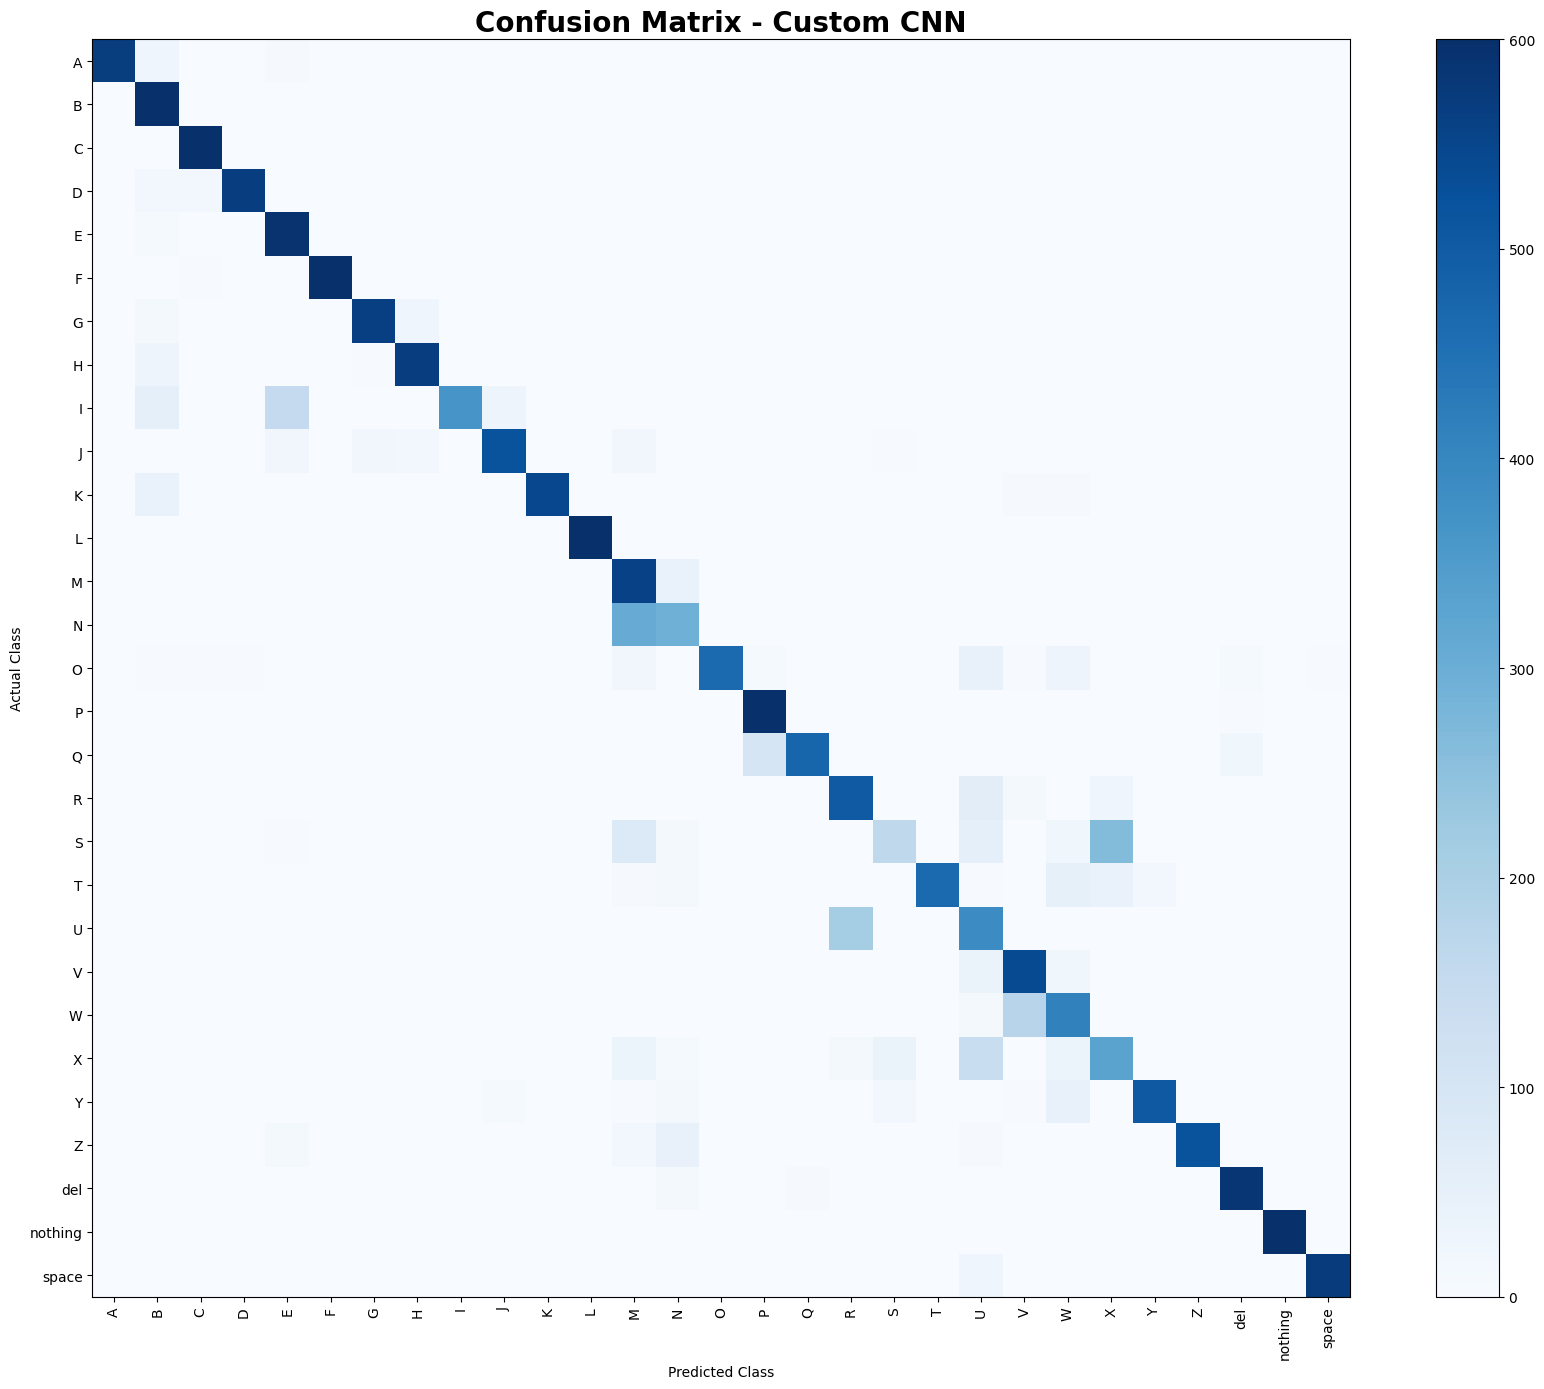

In [34]:
# 📌 Create confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 14))

plt.imshow(cm, cmap="Blues")

plt.title(f"Confusion Matrix - {best_model_name}", fontsize=20, fontweight="bold")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=90)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.savefig("/content/results/confusion_matrix.png")
plt.show()

In [35]:
# 🔍 Find most confused classes

cm_no_diagonal = cm.copy()
np.fill_diagonal(cm_no_diagonal, 0)

confusions = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):
        if cm_no_diagonal[true_idx, pred_idx] > 0:
            confusions.append({
                "Actual Class": class_names[true_idx],
                "Predicted Class": class_names[pred_idx],
                "Mistakes": cm_no_diagonal[true_idx, pred_idx]
            })

confusions_df = pd.DataFrame(confusions)
confusions_df = confusions_df.sort_values(by="Mistakes", ascending=False)

confusions_df.head(10)

,Actual Class,Predicted Class,Mistakes
24,N,M,306
50,S,X,263
63,U,R,211
67,W,V,178
12,I,E,150
72,X,U,139
40,Q,P,101
46,S,M,82
42,R,U,63
11,I,B,56


# 🔍 Error Analysis

The confusion matrix helps identify model weaknesses.

In ASL recognition, some letters are more difficult because their gestures look visually similar.  
For example, signs such as **M**, **N**, **S**, **T**, **U**, **V**, and **W** can be confused because they have similar hand shapes or finger positions.

Most errors can happen because of:

- similar hand gestures;
- different lighting;
- camera angle;
- hand rotation;
- background noise;
- image quality.

To reduce these errors, this project used:

- data augmentation;
- dropout;
- batch normalization;
- transfer learning with MobileNetV2;
- model comparison.

The model works well on clean images, but real-world webcam conditions may still be more challenging.

# 🤖 Single Image Prediction Test

This section tests the trained model on one image from the test folder.

The goal is to check whether the model can predict an unseen ASL image and show confidence score.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


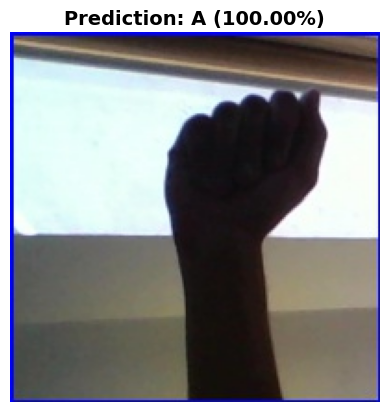

Predicted Class: A
Confidence: 100.00%


In [36]:
# 🤖 Test best model on one ASL image

test_image_path = "/content/asl_alphabet/asl_alphabet_test/asl_alphabet_test/A_test.jpg"

img = Image.open(test_image_path).convert("RGB")
img_resized = img.resize((img_size, img_size))

img_array = np.array(img_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = best_model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class} ({confidence:.2f}%)",
    fontsize=14,
    fontweight="bold"
)
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


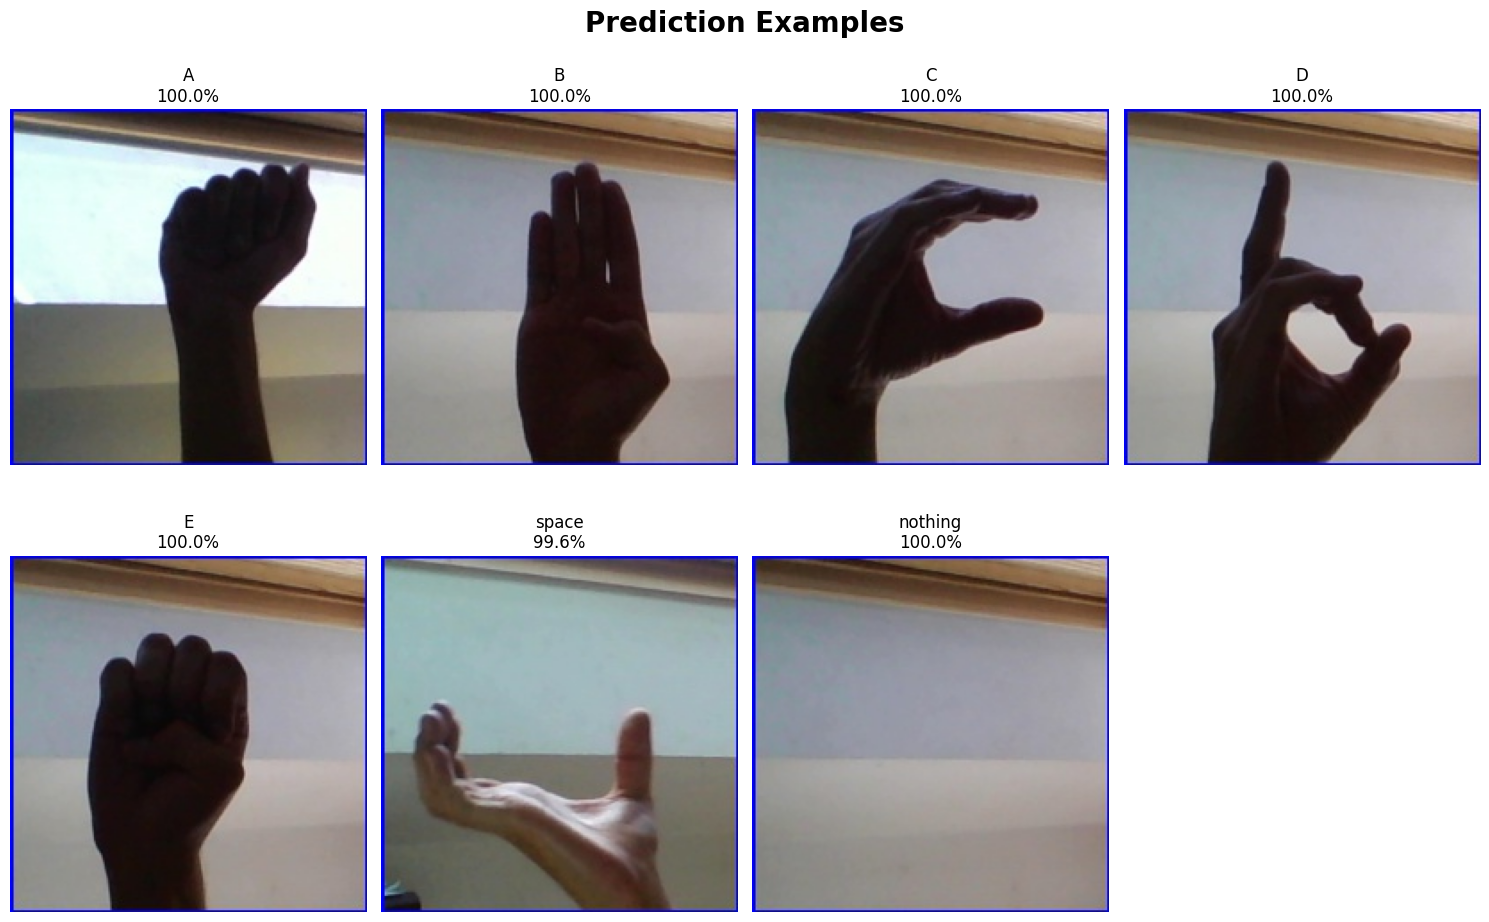

In [37]:
# 🧪 Test several images from ASL test folder

test_images = [
    "A_test.jpg",
    "B_test.jpg",
    "C_test.jpg",
    "D_test.jpg",
    "E_test.jpg",
    "space_test.jpg",
    "nothing_test.jpg"
]

plt.figure(figsize=(15, 10))

for i, image_name in enumerate(test_images):
    image_path = os.path.join(test_dir, image_name)

    if os.path.exists(image_path):
        img = Image.open(image_path).convert("RGB")
        img_resized = img.resize((img_size, img_size))

        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = best_model.predict(img_array)
        predicted_index = np.argmax(prediction)
        predicted_class = class_names[predicted_index]
        confidence = np.max(prediction) * 100

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{predicted_class}\n{confidence:.1f}%")

plt.suptitle("Prediction Examples", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/results/test_predictions.png")
plt.show()

# 🌐 Streamlit Web Application

A Streamlit application was developed to make the project interactive.

The application allows users to:

- upload ASL gesture images;
- run prediction using the trained model;
- view the predicted ASL letter;
- see prediction confidence.

Command to run the app locally:

```bash
streamlit run app.py

In [41]:
# 💾 Save class names for Streamlit app

import json

with open("/content/models/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved.")

Class names saved.


In [42]:
# 📝 Create simple Streamlit app.py file

app_code = '''
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image
import json

st.set_page_config(
    page_title="ASL Recognition App",
    page_icon="✋",
    layout="centered"
)

st.title("✋ ASL Sign Language Recognition")
st.write("Upload an ASL hand gesture image and the model will predict the sign.")

@st.cache_resource
def load_model_and_classes():
    model = tf.keras.models.load_model("models/best_asl_model.keras")
    with open("models/class_names.json", "r") as f:
        class_names = json.load(f)
    return model, class_names

model, class_names = load_model_and_classes()

uploaded_file = st.file_uploader(
    "Upload ASL image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    st.image(image, caption="Uploaded Image", use_container_width=True)

    img_size = 128
    img_resized = image.resize((img_size, img_size))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = np.max(prediction) * 100

    st.subheader("Prediction Result")
    st.success(f"Predicted Sign: {predicted_class}")
    st.info(f"Confidence: {confidence:.2f}%")
'''

with open("/content/app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [43]:
# 💾 Save best model as best_asl_model.keras for Streamlit

best_model.save("/content/models/best_asl_model.keras")

print("Best model saved as /content/models/best_asl_model.keras")
print("Best model:", best_model_name)

Best model saved as /content/models/best_asl_model.keras
Best model: Custom CNN


# 🏆 Final Results

The project successfully demonstrates a complete deep learning pipeline:

```text
Dataset → Preprocessing → Data Augmentation → Custom CNN → MobileNetV2 → Evaluation → Error Analysis → Prediction → Streamlit App